# Question 3: Pricing Exotic Options

**Setup:** Same stock (LLY), parameters, and option maturity as Problem 2. Daily price paths are simulated using $n = 126$ time steps ($\Delta t = T/n$). $N$ is chosen large enough that the standard error of each estimate is less than 0.1% of $S_0$ (i.e., SE $< 0.001 \times \$939.47 = \$0.9395$).

## Setup

### Imports

In [1]:
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import pandas as pd
import time

### Using Same Parameters as Q2

In [2]:
S0      = 939.47
K       = S0
T       = 0.5
r       = 0.0371
sigma   = 0.2690
n_steps = 126
mc_seed = 42

In [5]:
# SE criterion: < 0.1% of S0
se_threshold = 0.001 * S0
print(f"SE threshold (0.1% of S0 = ${S0:,.2f}): ${se_threshold:.4f}")

# Black-Scholes benchmark price from Q2.1
def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

bs_price = bs_call(S0, K, T, r, sigma)
print(f"Black-Scholes benchmark (European ATM call): ${bs_price:,.4f}")

SE threshold (0.1% of S0 = $939.47): $0.9395
Black-Scholes benchmark (European ATM call): $79.4962


## 3(a) Arithmetic Asian Call Option

The **arithmetic Asian call** replaces the terminal stock price $S_T$ with the time-average price $\bar{S}$ computed over the life of the option:

$$\text{Payoff} = \max(\bar{S} - K,\; 0), \qquad \bar{S} = \frac{1}{n}\sum_{i=1}^{n} S_{t_i}$$

Because no closed-form solution exists for this payoff under GBM, Monte Carlo simulation is required. We simulate full daily price paths and track the running sum of prices at each step, then compute the average at expiry.

### Simulating GBM paths for the Arithmetic Asian Call Option

In [ ]:
def simulate_paths_asian_lookback(S0, r, sigma, T, n_steps, n_paths, rng):
    """
    Simulate GBM paths via Euler-Maruyama.
    Returns:
        S_T       : terminal prices (shape: n_paths)
        S_bar     : arithmetic average price over all steps (shape: n_paths)
        S_min     : minimum price reached over all steps (shape: n_paths)
    Memory-efficient: only stores current S, running sum, and running min.
    """
    dt      = T / n_steps
    sqrt_dt = np.sqrt(dt)

    # Initialize arrays for current price, running sum, and running min
    S       = np.full(n_paths, S0, dtype=np.float64)
    S_sum   = np.zeros(n_paths, dtype=np.float64)
    S_min   = np.full(n_paths, S0, dtype=np.float64)

    for _ in range(n_steps):
        Z = rng.standard_normal(n_paths)
        S = S + r * S * dt + sigma * S * sqrt_dt * Z
        S_sum += S
        np.minimum(S_min, S, out=S_min)

    S_bar = S_sum / n_steps  # arithmetic average price
    return S, S_bar, S_min


### Running the Simulation

In [11]:
# ── Determine N needed for SE < se_threshold ─────────────────────────────────
# Start with N = 1,000,000 (generous) and verify criterion is met.
N = 1000000
rng = np.random.default_rng(mc_seed)

t0 = time.perf_counter()
S_T, S_bar, S_min = simulate_paths_asian_lookback(S0, r, sigma, T, n_steps, N, rng)
t_sim = time.perf_counter() - t0


### Asian Call Payoffs

In [12]:
disc = np.exp(-r * T)
asian_payoffs  = disc * np.maximum(S_bar - K, 0.0)

asian_price = float(np.mean(asian_payoffs))
asian_se    = float(np.std(asian_payoffs, ddof=1) / np.sqrt(N))
asian_ci_lo = asian_price - 1.96 * asian_se
asian_ci_hi = asian_price + 1.96 * asian_se


In [10]:
print("Question 3(a): Arithmetic Asian Call Option")
print(f"  Paths simulated (N)         : {N:,}")
print(f"  Simulation time             : {t_sim:.2f} s")
print()
print(f"  MC Asian call price         : ${asian_price:,.4f}")
print(f"  Standard error (SE)         : ${asian_se:.4f}")
print(f"  SE threshold (0.1% of S0)   : ${se_threshold:.4f}")
print(f"  SE criterion met?           : {'YES' if asian_se < se_threshold else 'NO'}")
print(f"  95% confidence interval     : [${asian_ci_lo:,.4f},  ${asian_ci_hi:,.4f}]")
print()
print(f"  Black-Scholes (vanilla call): ${bs_price:,.4f}")
print(f"  Asian vs. Vanilla           : ${asian_price - bs_price:+,.4f}"
      f"  ({(asian_price/bs_price - 1)*100:+.2f}%)")

Question 3(a): Arithmetic Asian Call Option
  Paths simulated (N)         : 1,000,000
  Simulation time             : 1.29 s

  MC Asian call price         : $45.3737
  Standard error (SE)         : $0.0679
  SE threshold (0.1% of S0)   : $0.9395
  SE criterion met?           : YES
  95% confidence interval     : [$45.2407,  $45.5067]

  Black-Scholes (vanilla call): $79.4962
  Asian vs. Vanilla           : $-34.1225  (-42.92%)


## 3(b) Floating-Strike Lookback Call Option

A **floating-strike lookback call** sets the strike equal to the minimum stock price realized over the life of the option—giving the holder the "perfect hindsight" of buying at the lowest price and selling at the final price. The payoff is:

$$\text{Payoff} = S_T - \min_{0 \le t \le T} S_t$$

Unlike a vanilla call, this payoff is *always non-negative* (since $S_T \ge \min S_t$ by definition), so the lookback option is inherently more expensive than a vanilla call that can expire worthless.

In [3]:
# ── Lookback call payoffs (reuse same simulated paths) ────────────────────────
# Payoff = S_T - min(S_t over all t in [0,T])
# Note: S_min already tracks the running minimum including S0
lookback_payoffs = disc * (S_T - S_min)

lookback_price = float(np.mean(lookback_payoffs))
lookback_se    = float(np.std(lookback_payoffs, ddof=1) / np.sqrt(N))
lookback_ci_lo = lookback_price - 1.96 * lookback_se
lookback_ci_hi = lookback_price + 1.96 * lookback_se

print("Question 3(b): Floating-Strike Lookback Call Option")
print(f"  Paths simulated (N)         : {N:,}")
print()
print(f"  MC Lookback call price      : ${lookback_price:,.4f}")
print(f"  Standard error (SE)         : ${lookback_se:.4f}")
print(f"  SE threshold (0.1% of S0)   : ${se_threshold:.4f}")
print(f"  SE criterion met?           : {'YES' if lookback_se < se_threshold else 'NO'}")
print(f"  95% confidence interval     : [${lookback_ci_lo:,.4f},  ${lookback_ci_hi:,.4f}]")
print()
print(f"  Black-Scholes (vanilla call): ${bs_price:,.4f}")
print(f"  Lookback premium over vanilla: ${lookback_price - bs_price:+,.4f}"
      f"  ({(lookback_price/bs_price - 1)*100:+.2f}%)")

# Verify lookback payoffs are always non-negative (should be True)
print(f"\n  All lookback payoffs >= 0: {bool(np.all(lookback_payoffs >= 0))}")

Question 3(b): Floating-Strike Lookback Call Option
  Paths simulated (N)         : 1,000,000

  MC Lookback call price      : $134.3279
  Standard error (SE)         : $0.1235
  SE threshold (0.1% of S0)   : $0.9395
  SE criterion met?           : YES
  95% confidence interval     : [$134.0858,  $134.5700]

  Black-Scholes (vanilla call): $79.4962
  Lookback premium over vanilla: $+54.8318  (+68.97%)

  All lookback payoffs >= 0: True


## 3(c) Comparison Table

We now compare all three options side by side: the vanilla European call (priced via Black-Scholes), the arithmetic Asian call (MC), and the floating-strike lookback call (MC).

Question 3(c): Comparison Table — LLY ATM 6-Month Options
                       Option              Pricing Method  Price ($)  SE ($)               Payoff Structure
        Vanilla European Call Black-Scholes (closed-form)    79.4962  0.0000                max(S_T − K, 0)
        Arithmetic Asian Call   Monte Carlo (N=1,000,000)    45.3737  0.0679 max(S̄ − K, 0),  S̄ = avg(S_t)
Floating-Strike Lookback Call   Monte Carlo (N=1,000,000)   134.3279  0.1235                 S_T − min(S_t)



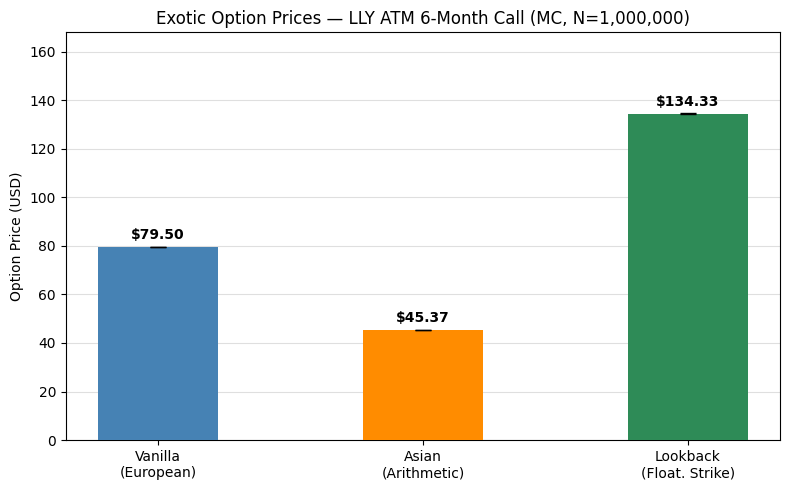


Summary of price drivers:
  Asian discount vs. Vanilla  : $-34.1225  (-42.92%)
  Lookback premium vs. Vanilla: $+54.8318  (+68.97%)


In [4]:
comparison = pd.DataFrame([
    {
        "Option"        : "Vanilla European Call",
        "Pricing Method": "Black-Scholes (closed-form)",
        "Price ($)"     : bs_price,
        "SE ($)"        : 0.0,       # exact closed-form: no sampling error
        "Payoff Structure": "max(S_T − K, 0)"
    },
    {
        "Option"        : "Arithmetic Asian Call",
        "Pricing Method": "Monte Carlo (N=1,000,000)",
        "Price ($)"     : asian_price,
        "SE ($)"        : asian_se,
        "Payoff Structure": "max(S̄ − K, 0),  S̄ = avg(S_t)"
    },
    {
        "Option"        : "Floating-Strike Lookback Call",
        "Pricing Method": "Monte Carlo (N=1,000,000)",
        "Price ($)"     : lookback_price,
        "SE ($)"        : lookback_se,
        "Payoff Structure": "S_T − min(S_t)"
    },
])

print("Question 3(c): Comparison Table — LLY ATM 6-Month Options")
print("=" * 76)
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
labels = ["Vanilla\n(European)", "Asian\n(Arithmetic)", "Lookback\n(Float. Strike)"]
prices = [bs_price, asian_price, lookback_price]
ses    = [0.0,       asian_se,   lookback_se]
colors = ["steelblue", "darkorange", "seagreen"]

bars = ax.bar(labels, prices, color=colors, width=0.45, zorder=3)
ax.errorbar(
    range(len(labels)), prices, yerr=[1.96 * s for s in ses],
    fmt="none", color="black", capsize=6, linewidth=1.5, zorder=4
)
for bar, price in zip(bars, prices):
    ax.text(
        bar.get_x() + bar.get_width() / 2, price + 2,
        f"${price:,.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_ylabel("Option Price (USD)")
ax.set_title("Exotic Option Prices — LLY ATM 6-Month Call (MC, N=1,000,000)")
ax.set_ylim(0, max(prices) * 1.25)
ax.grid(axis="y", alpha=0.4, zorder=0)
plt.tight_layout()
plt.show()

print()
print("Summary of price drivers:")
print(f"  Asian discount vs. Vanilla  : ${asian_price - bs_price:+.4f}"
      f"  ({(asian_price/bs_price - 1)*100:+.2f}%)")
print(f"  Lookback premium vs. Vanilla: ${lookback_price - bs_price:+.4f}"
      f"  ({(lookback_price/bs_price - 1)*100:+.2f}%)")